# EDA - Riesgo de enfermedad coronaria a 10 años

En este análisis exploratorio de datos (EDA) voy a estudiar el dataset de Framingham con el objetivo de entender qué características demográficas, clínicas y de estilo de vida se asocian con un mayor riesgo de desarrollar enfermedad coronaria en los próximos 10 años.

La variable objetivo del análisis es `TenYearCHD`, que indica si un paciente desarrolla enfermedad coronaria a 10 años.

Durante el EDA analizaré:

- Estructura general del dataset.
- Valores duplicados y valores nulos.
- Distribución de las variables.
- Presencia de valores atípicos.
- Relación de las variables con la variable objetivo.
- Contraste de hipótesis iniciales.
- Variables más relevantes para fases posteriores de modelado.

## Planteamiento de hipótesis iniciales

Antes de comenzar el análisis, planteo una serie de hipótesis basadas en el contexto del problema.

El objetivo es identificar qué características influyen en la probabilidad de que un paciente desarrolle enfermedad coronaria en los próximos 10 años (`TenYearCHD`).

### Hipótesis principales

- La edad (`age`) tendrá una fuerte relación positiva con el riesgo, ya que el riesgo cardiovascular suele aumentar con la edad.
- La presión arterial (`sysBP`, `diaBP`) será una de las variables más influyentes, debido a su relación directa con enfermedades cardiovasculares.
- El colesterol (`totChol`) y la glucosa (`glucose`) estarán asociados a mayor riesgo.
- El índice de masa corporal (`BMI`) podría influir, aunque posiblemente de forma más moderada.
- Variables como `currentSmoker` y `cigsPerDay` pueden tener impacto por el efecto del tabaquismo.
- Variables médicas como `diabetes` o `prevalentHyp` probablemente tendrán una relación importante con la variable objetivo.

### Variables con menor impacto esperado

- `education` podría tener una relación indirecta, asociada a hábitos de vida o acceso a información sanitaria.
- `heartRate` podría no ser una variable determinante por sí sola.

Estas hipótesis reflejan mi criterio inicial sobre qué variables pueden tener mayor relación con el desarrollo de enfermedad coronaria. A lo largo del EDA contrastaré si estas ideas se confirman o no con los datos.

## Set Up

En este apartado importo las librerías necesarias y cargo el dataset original.

In [56]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [57]:
from pathlib import Path

# Ruta esperada si el notebook está dentro de la carpeta src
data_path = Path("../data/framingham.csv")

# Ruta alternativa por si se ejecuta desde la raíz del proyecto
if not data_path.exists():
    data_path = Path("data/framingham.csv")

# Ruta alternativa por si el CSV está en la misma carpeta que el notebook
if not data_path.exists():
    data_path = Path("framingham.csv")

df = pd.read_csv(data_path)

# Creo una copia de trabajo para no modificar el dataset original
df_clean = df.copy()

## Data Preview

Realizo una primera visualización del dataset para comprobar que se ha cargado correctamente.

In [58]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [59]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [61]:
df.shape

(4240, 16)

In [62]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [63]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


## Inspección inicial del dataset

A continuación, realizo una primera exploración del dataset con el objetivo de comprender su estructura general.

Utilizo funciones como `info()`, `shape`, `dtypes` y `describe()` para obtener información sobre:

- Número de filas y columnas.
- Tipos de variables.
- Presencia inicial de valores nulos.
- Estadísticas básicas como media, desviación estándar, mínimos y máximos.

Este paso es fundamental para detectar posibles problemas en los datos y definir la estrategia de análisis posterior.

## Clasificación inicial de variables

Identifico qué variables se analizarán como numéricas y cuáles como categóricas/binarias.

In [64]:
target = "TenYearCHD"

numeric_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

cat_cols = [
    "male", "education", "currentSmoker", "BPMeds",
    "prevalentStroke", "prevalentHyp", "diabetes"
]

binary_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes"]

print(f"Variable objetivo: {target}")
print(f"Variables numéricas: {numeric_cols}")
print(f"Variables categóricas/binarias: {cat_cols}")

Variable objetivo: TenYearCHD
Variables numéricas: ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Variables categóricas/binarias: ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']


Aunque algunas variables están codificadas como números (`0` y `1`), conceptualmente representan categorías. Por ejemplo, `currentSmoker`, `diabetes` o `prevalentHyp` no son variables continuas, sino variables binarias.

Por este motivo, durante el análisis se tratarán como variables categóricas, utilizando frecuencias, porcentajes y gráficos de barras.

## Detección de registros duplicados

In [65]:
df.duplicated().sum()

np.int64(0)

El resultado obtenido es 0, lo que indica que no existen observaciones duplicadas en el dataset.

Esto es positivo, ya que evita posibles sesgos en el análisis derivados de la repetición de información.

## Análisis de valores nulos

In [66]:
nulls = df.isnull().sum()
nulls_percent = (nulls / len(df)) * 100

nulls_df = pd.DataFrame({
    "nulos": nulls,
    "porcentaje": nulls_percent
})

nulls_df.sort_values(by="porcentaje", ascending=False)

,nulos,porcentaje
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585
male,0,0.000000
age,0,0.000000
currentSmoker,0,0.000000


Tras analizar los valores nulos del dataset, observo que la mayoría de las variables presentan una cantidad baja de datos faltantes.

La variable con mayor porcentaje de nulos es `glucose`, con aproximadamente un 9.15%, seguida de `education`, con alrededor de un 2.47%. El resto de variables presentan porcentajes inferiores al 2%.

Dado que ninguna variable presenta un porcentaje excesivamente alto de valores nulos, decido no eliminar ninguna columna en esta fase del análisis.

Para evitar introducir sesgos, primero analizo la distribución de los datos y posteriormente aplico una imputación justificada sobre `df_clean`.

## Tratamiento de valores nulos

In [67]:
# Imputación de variables numéricas con mediana
for col in ["glucose", "totChol", "cigsPerDay", "BMI", "heartRate"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Imputación de variables categóricas/binarias con moda
for col in ["education", "BPMeds"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Comprobación final de nulos
df_clean.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Para las variables numéricas (`glucose`, `totChol`, `cigsPerDay`, `BMI` y `heartRate`) utilizo la mediana, ya que es más robusta frente a valores atípicos que la media.

Para las variables categóricas o binarias (`education` y `BPMeds`) utilizo la moda, porque representa la categoría más frecuente.

Este tratamiento se realiza sobre `df_clean`, manteniendo intacto el dataset original.

> Nota sobre data leakage: en este EDA se realiza la imputación para poder analizar el dataset limpio. En una fase posterior de modelado, la imputación debería ajustarse únicamente con los datos de entrenamiento para evitar leakage.

## Distribución de la variable objetivo

TenYearCHD
0    3596
1     644
Name: count, dtype: int64
TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


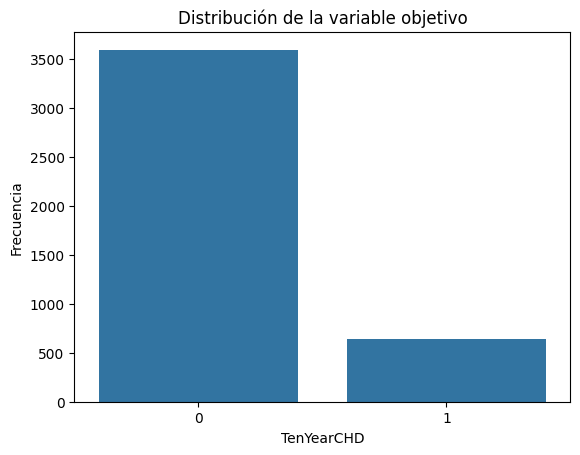

In [68]:
target_counts = df_clean[target].value_counts()
target_percent = df_clean[target].value_counts(normalize=True) * 100

print(target_counts)
print(target_percent)

sns.countplot(data=df_clean, x=target)
plt.title("Distribución de la variable objetivo")
plt.xlabel("TenYearCHD")
plt.ylabel("Frecuencia")
plt.show()

La variable objetivo `TenYearCHD` está desbalanceada, ya que la mayoría de pacientes no desarrolla enfermedad coronaria a 10 años.

Esto es importante porque indica que el evento positivo (`TenYearCHD = 1`) es menos frecuente, algo habitual en problemas médicos.

Este desbalance deberá tenerse en cuenta en fases posteriores si se construyen modelos predictivos.

## Análisis univariable: variables categóricas y binarias

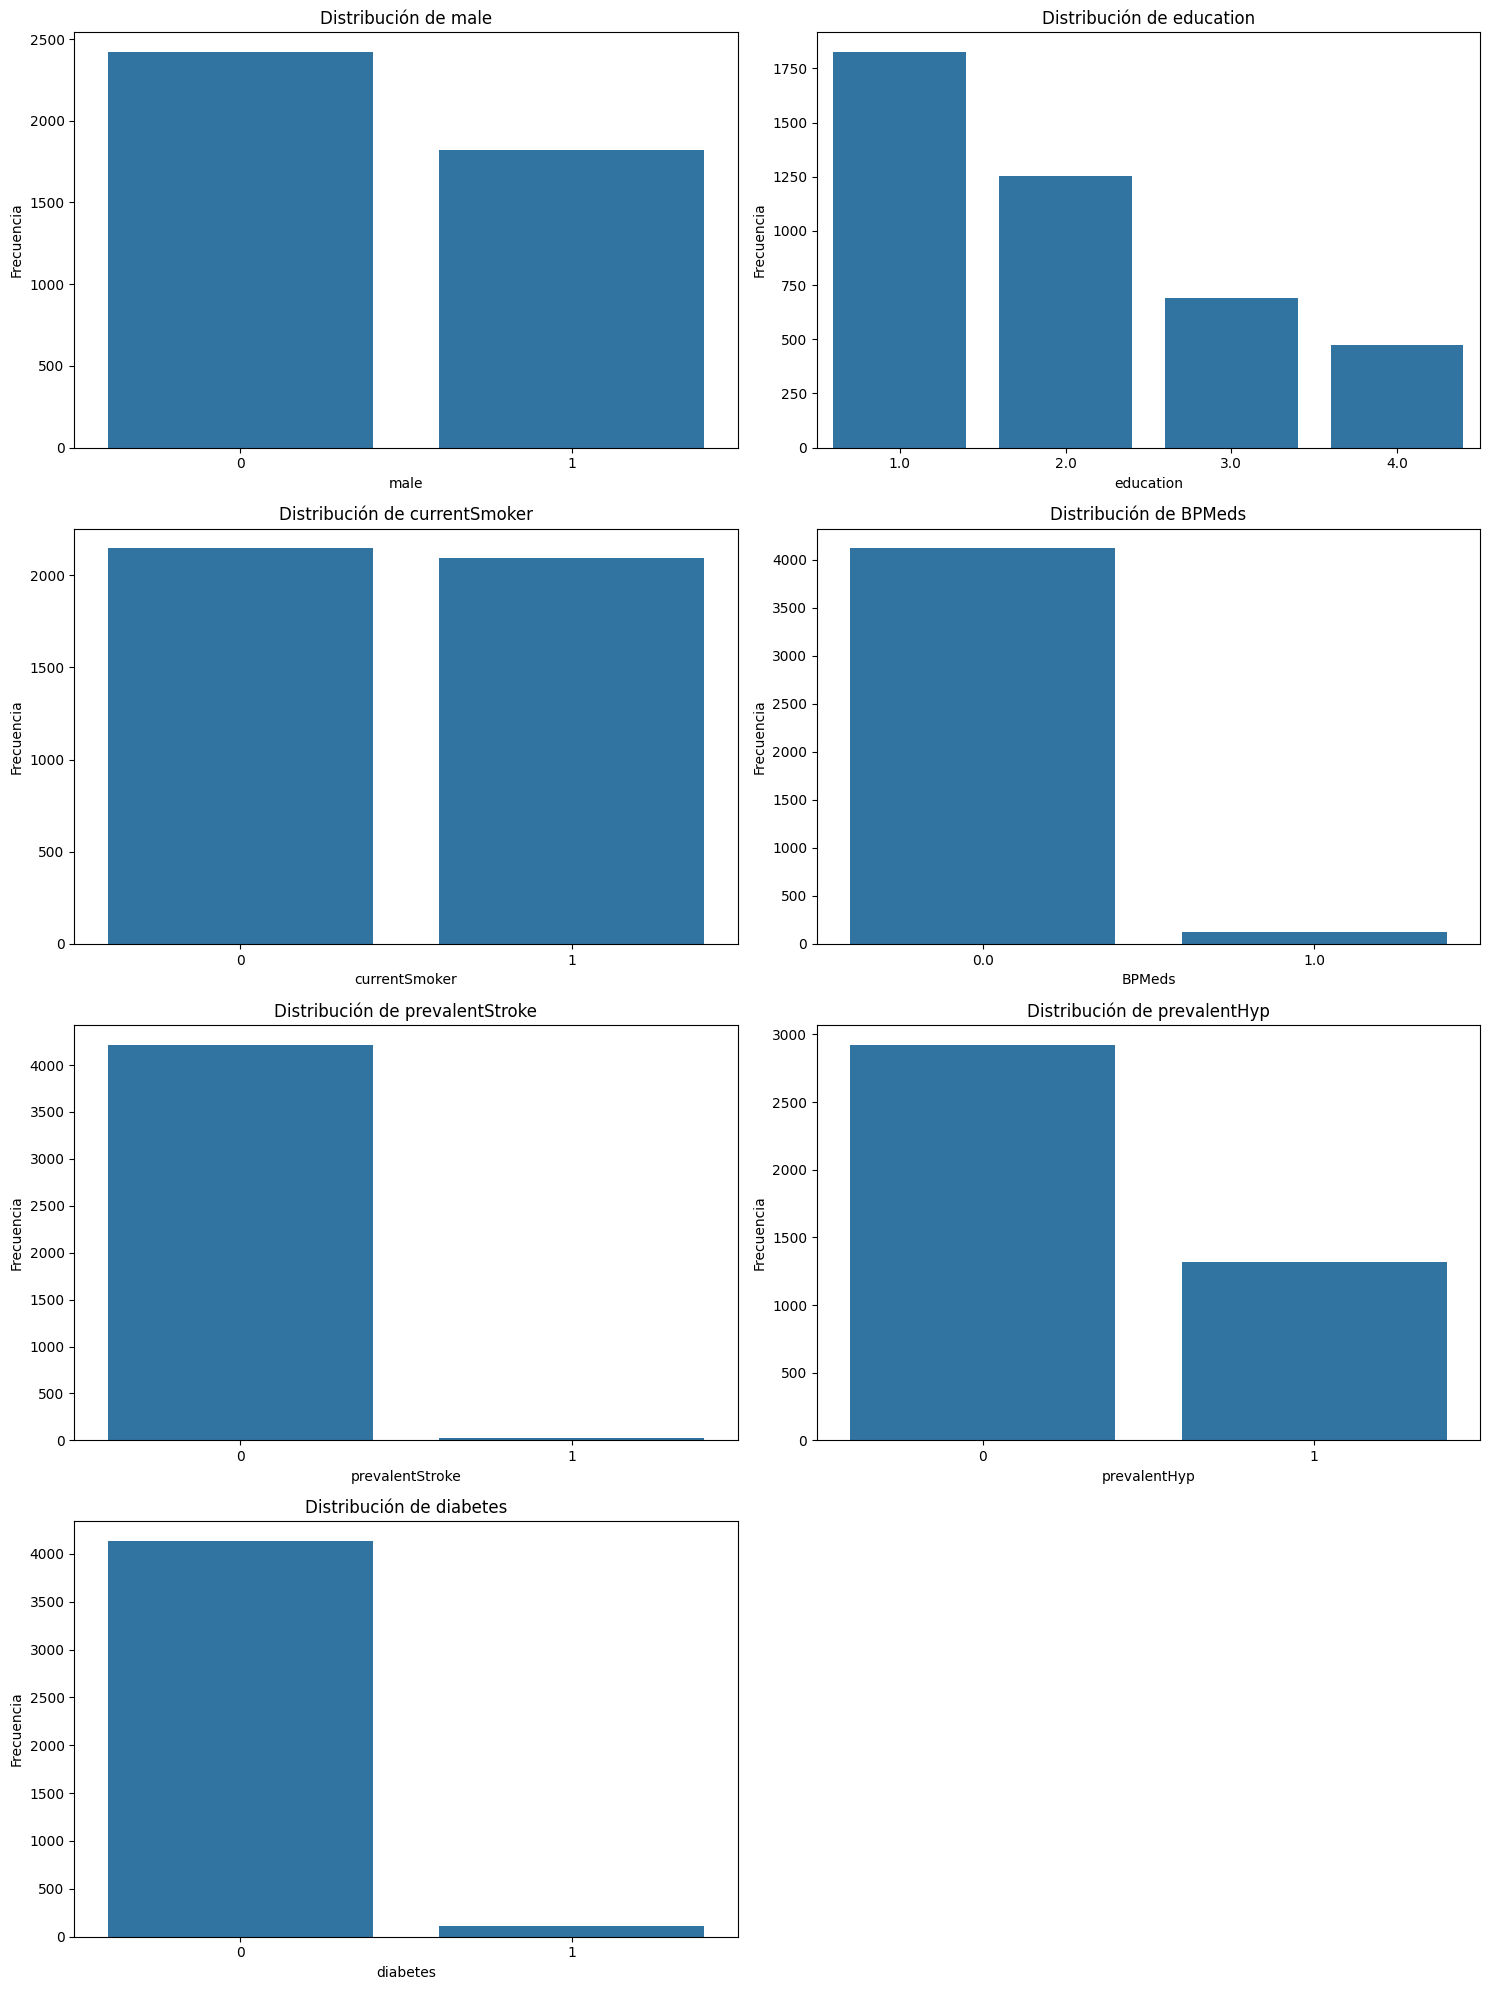

In [69]:
fig, axs = plt.subplots(
    nrows=(len(cat_cols) + 1) // 2,
    ncols=2,
    figsize=(15, 5 * ((len(cat_cols) + 1) // 2))
)

axs = axs.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, ax=axs[i], order=df_clean[col].value_counts().index)
    axs[i].set_title(f"Distribución de {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [70]:
for col in cat_cols:
    print(f"\n{col}")
    print(df_clean[col].value_counts(normalize=True) * 100)


male
male
0    57.075472
1    42.924528
Name: proportion, dtype: float64

education
education
1.0    43.042453
2.0    29.551887
3.0    16.250000
4.0    11.155660
Name: proportion, dtype: float64

currentSmoker
currentSmoker
0    50.589623
1    49.410377
Name: proportion, dtype: float64

BPMeds
BPMeds
0.0    97.075472
1.0     2.924528
Name: proportion, dtype: float64

prevalentStroke
prevalentStroke
0    99.410377
1     0.589623
Name: proportion, dtype: float64

prevalentHyp
prevalentHyp
0    68.938679
1    31.061321
Name: proportion, dtype: float64

diabetes
diabetes
0    97.429245
1     2.570755
Name: proportion, dtype: float64


En este apartado analizo las variables categóricas y binarias del dataset.

Se observan varios comportamientos:

- `male` muestra una ligera mayoría de mujeres frente a hombres.
- `currentSmoker` está prácticamente balanceada.
- `prevalentHyp` presenta una proporción relevante de pacientes con hipertensión.
- `BPMeds`, `diabetes` y `prevalentStroke` están muy desbalanceadas, con pocos casos positivos.

Este desbalance en algunas variables clínicas no implica que deban eliminarse, ya que pueden representar condiciones médicas importantes. Sin embargo, deberá tenerse en cuenta al interpretar los resultados.

## Análisis univariable: variables numéricas


----- age -----


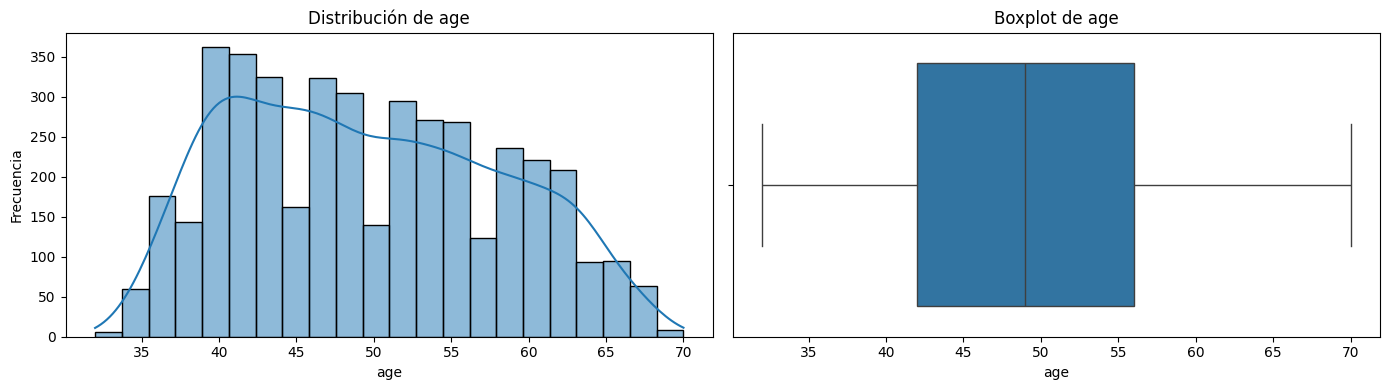

Skewness: 0.22878605874310656
Kurtosis: -0.990142826228277

----- cigsPerDay -----


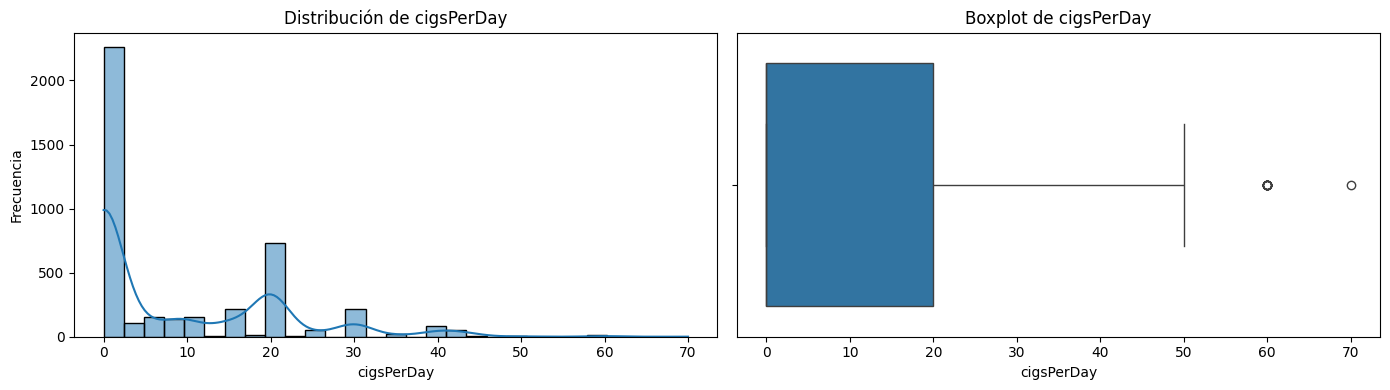

Skewness: 1.256166709530087
Kurtosis: 1.0411365721918466

----- totChol -----


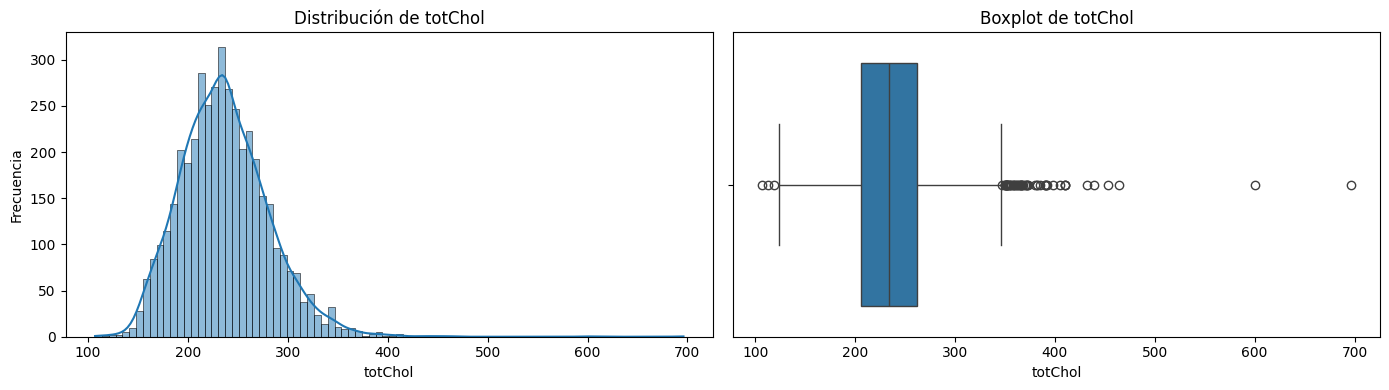

Skewness: 0.8788484266581921
Kurtosis: 4.210436196102998

----- sysBP -----


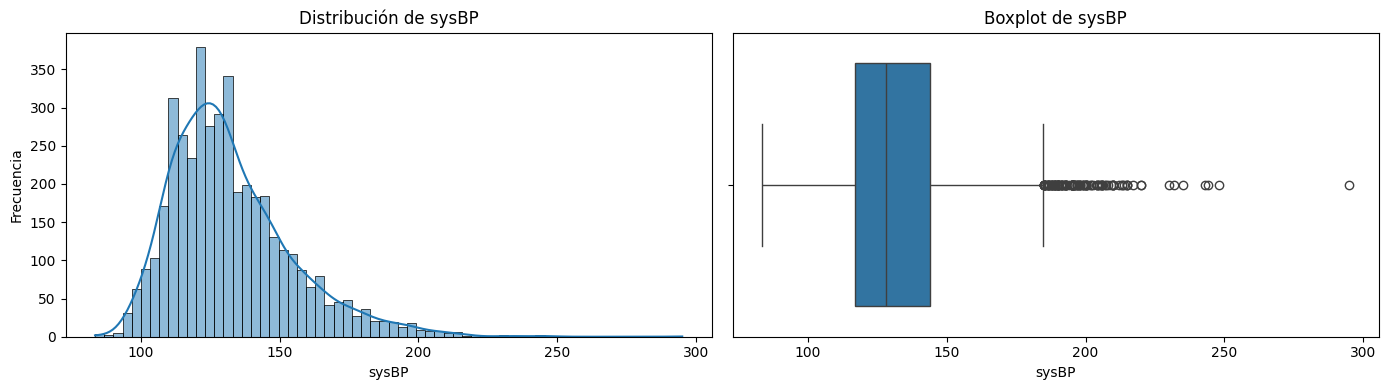

Skewness: 1.1448798241135858
Kurtosis: 2.1526664938197957

----- diaBP -----


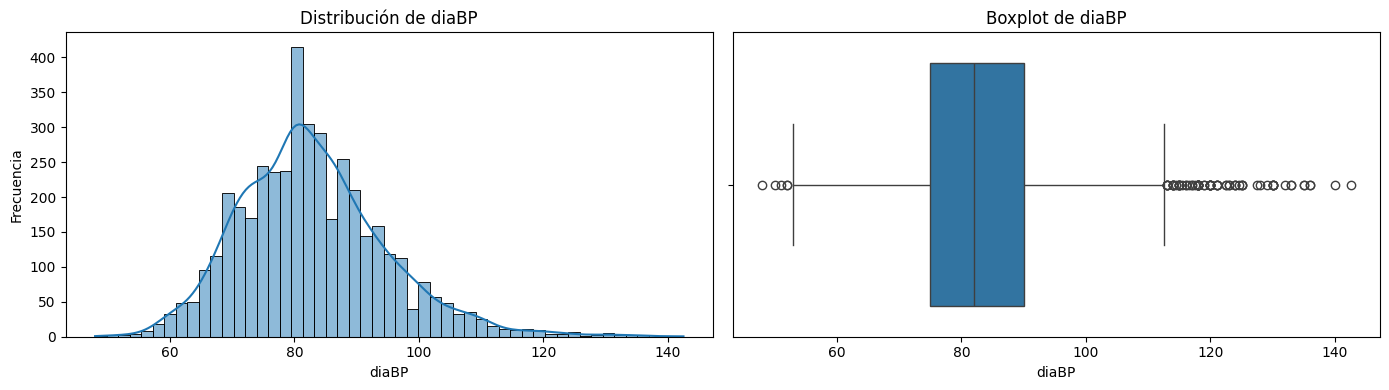

Skewness: 0.7129978589624182
Kurtosis: 1.2723961617339175

----- BMI -----


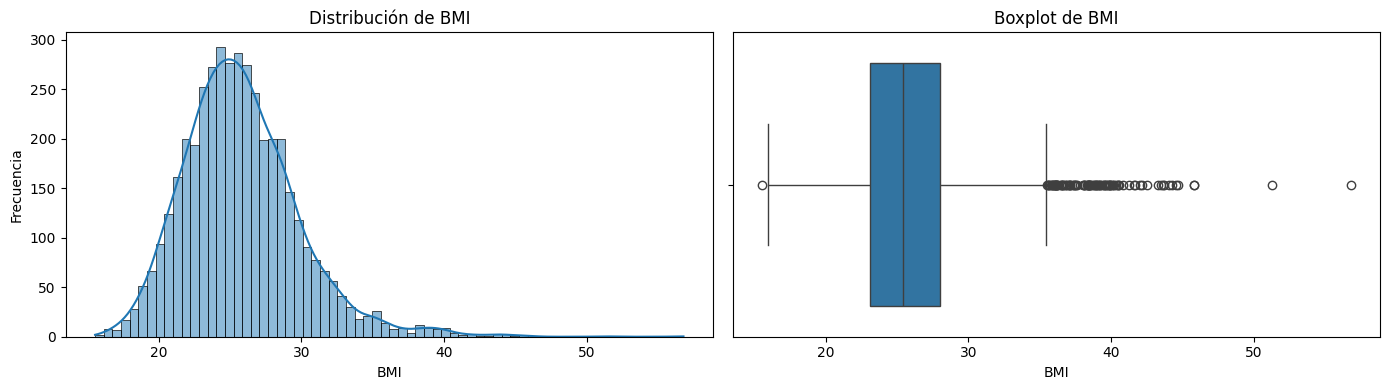

Skewness: 0.9852971568870522
Kurtosis: 2.6794335673552077

----- heartRate -----


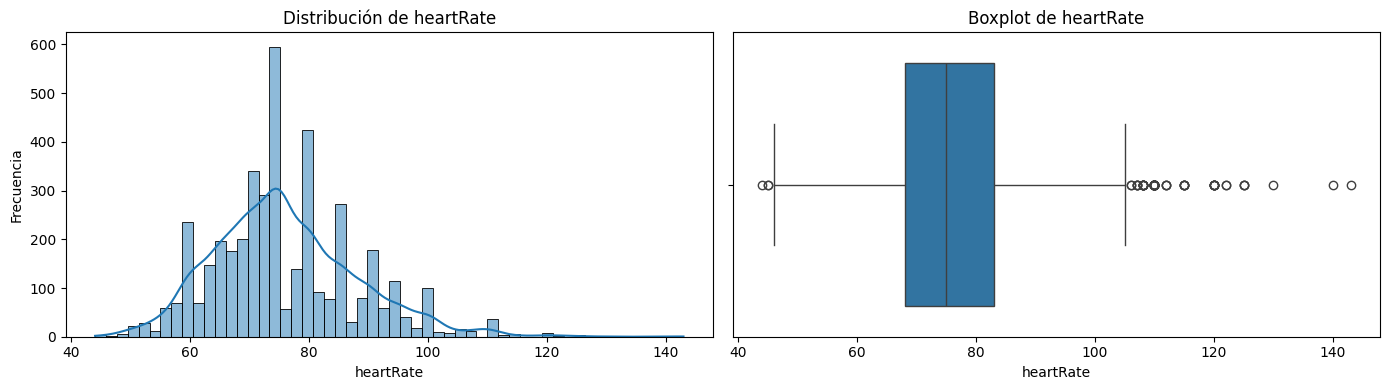

Skewness: 0.6442701714283919
Kurtosis: 0.9058664681783055

----- glucose -----


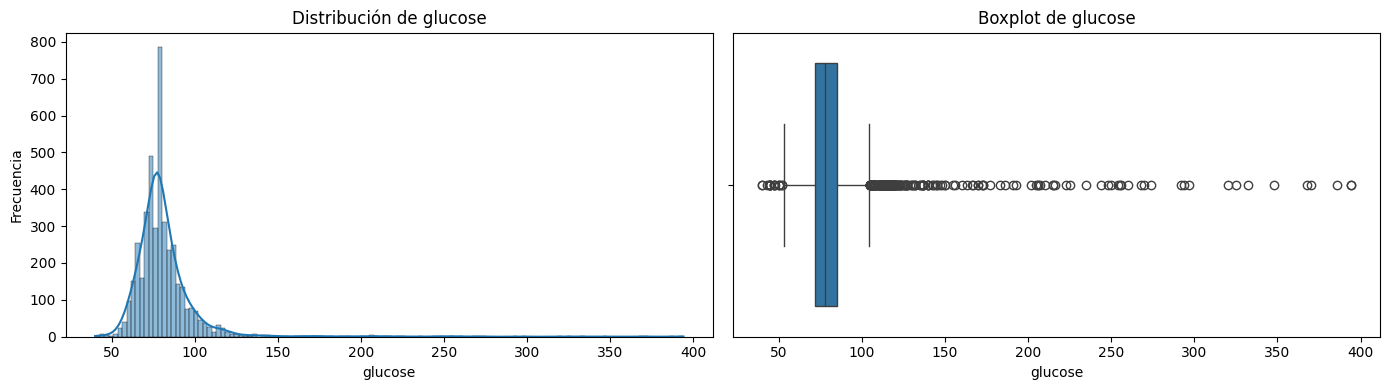

Skewness: 6.5406130231040205
Kurtosis: 64.90841145529399


In [71]:
for col in numeric_cols:
    print(f"\n----- {col} -----")

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

    sns.histplot(df_clean[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(x=df_clean[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    print("Skewness:", skew(df_clean[col].dropna()))
    print("Kurtosis:", kurtosis(df_clean[col].dropna()))

En este apartado analizo de forma conjunta las variables numéricas del dataset, evaluando su distribución, la presencia de valores atípicos y la forma de cada variable.

En general, se pueden identificar tres tipos de comportamientos:

- Variables como `age`, `diaBP`, `BMI` y `heartRate` presentan distribuciones relativamente equilibradas.
- Variables como `totChol` y `sysBP` presentan ligera asimetría positiva y algunos valores elevados.
- Variables como `cigsPerDay` y `glucose` presentan mayor asimetría positiva. En `cigsPerDay`, esto se debe a la presencia de muchos valores cero, correspondientes a pacientes no fumadores.

La presencia de outliers en variables clínicas no implica necesariamente errores. En muchos casos pueden representar pacientes reales con valores elevados de presión arterial, glucosa o colesterol.

## Análisis de cardinalidad

In [72]:
df_clean.nunique().sort_values(ascending=False)

BMI                1364
totChol             248
sysBP               234
diaBP               146
glucose             143
heartRate            73
age                  39
cigsPerDay           33
education             4
male                  2
currentSmoker         2
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
TenYearCHD            2
dtype: int64

El análisis de cardinalidad permite identificar cuántos valores únicos tiene cada variable.

En este dataset no existen variables categóricas con una cardinalidad extremadamente alta, por lo que no es necesario aplicar agrupaciones complejas en esta fase.

Las variables numéricas presentan mayor variabilidad, mientras que las variables binarias tienen únicamente dos categorías.

## Análisis de valores atípicos

In [73]:
df_clean[numeric_cols].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
age,4240.0,49.580189,8.572942,32.00,42.0000,49.0,56.0000,62.000,64.0000,67.0000,70.0
cigsPerDay,4240.0,8.944340,11.904777,0.00,0.0000,0.0,20.0000,25.000,30.0000,43.0000,70.0
totChol,4240.0,236.667689,44.328480,107.00,206.0000,234.0,262.0000,292.000,312.0000,353.6100,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.0000,128.0,144.0000,162.000,175.0000,200.0000,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.0000,82.0,90.0000,98.000,104.5250,118.0000,142.5
BMI,4240.0,25.799005,4.070775,15.54,23.0775,25.4,28.0325,30.761,32.7705,38.9522,56.8
heartRate,4240.0,75.878774,12.023937,44.00,68.0000,75.0,83.0000,92.000,98.0000,110.0000,143.0
glucose,4240.0,81.600943,22.860340,40.00,72.0000,78.0,85.0000,97.000,107.0000,170.0000,394.0


A partir de los boxplots y los percentiles, se observan valores atípicos en variables como `glucose`, `totChol`, `sysBP`, `diaBP` y `BMI`.

Sin embargo, en este contexto estos valores pueden representar casos clínicos reales, como pacientes con niveles elevados de glucosa, colesterol o presión arterial.

Por este motivo, no se eliminan los outliers de forma automática. Eliminarlos podría hacer que se pierda información importante sobre pacientes de mayor riesgo, que precisamente son relevantes para la pregunta de investigación.

## Experimento de winsorización

In [74]:
def windsorize_upper(df, columns, upper_percentile=0.99):
    """
    Limita los valores superiores de cada columna al percentil indicado.
    No modifica el dataset original, solo devuelve una copia transformada.
    """
    df_copy = df.copy()

    for col in columns:
        upper_limit = df_copy[col].quantile(upper_percentile)
        df_copy[col] = np.where(df_copy[col] > upper_limit, upper_limit, df_copy[col])

    return df_copy


cols_to_windsorize = ["cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]

df_windsorized = windsorize_upper(df_clean, cols_to_windsorize, upper_percentile=0.99)

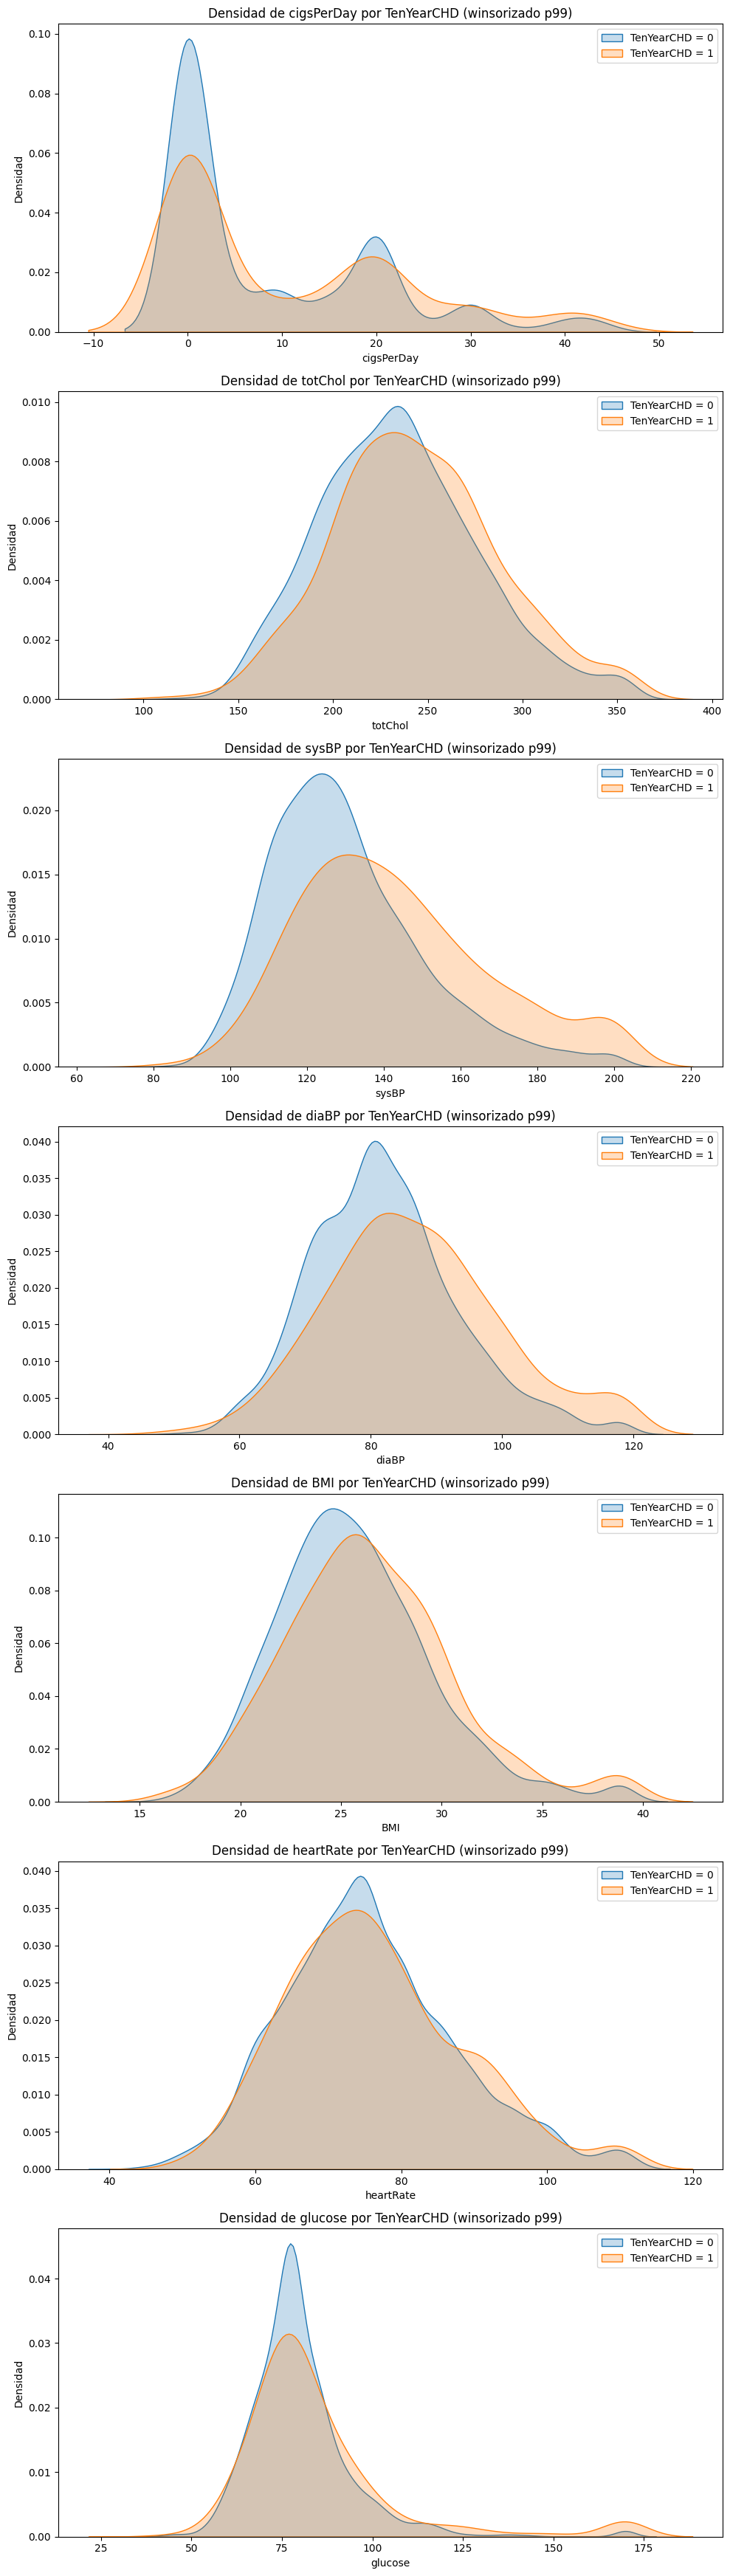

In [75]:
fig, axs = plt.subplots(
    nrows=len(cols_to_windsorize),
    ncols=1,
    figsize=(10, 5 * len(cols_to_windsorize))
)

for i, col in enumerate(cols_to_windsorize):
    sns.kdeplot(
        data=df_windsorized[df_windsorized[target] == 0],
        x=col,
        ax=axs[i],
        label=f"{target} = 0",
        fill=True
    )

    sns.kdeplot(
        data=df_windsorized[df_windsorized[target] == 1],
        x=col,
        ax=axs[i],
        label=f"{target} = 1",
        fill=True
    )

    axs[i].set_title(f"Densidad de {col} por {target} (winsorizado p99)")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Densidad")
    axs[i].legend()

plt.tight_layout()
plt.show()

Como parte del análisis de outliers, realizo un experimento de winsorización sobre algunas variables numéricas.

La winsorización consiste en limitar los valores extremos superiores a un percentil determinado, en este caso el percentil 99. El objetivo es comprobar cómo se comportan las distribuciones si se reduce el impacto visual de los valores extremos.

Este proceso se realiza sobre una copia (`df_windsorized`) y no sustituye al dataset limpio principal (`df_clean`).

Al tratarse de variables clínicas, los valores extremos pueden ser pacientes reales con mayor riesgo cardiovascular, por lo que no se eliminan ni se modifican definitivamente.

## Matriz de correlación

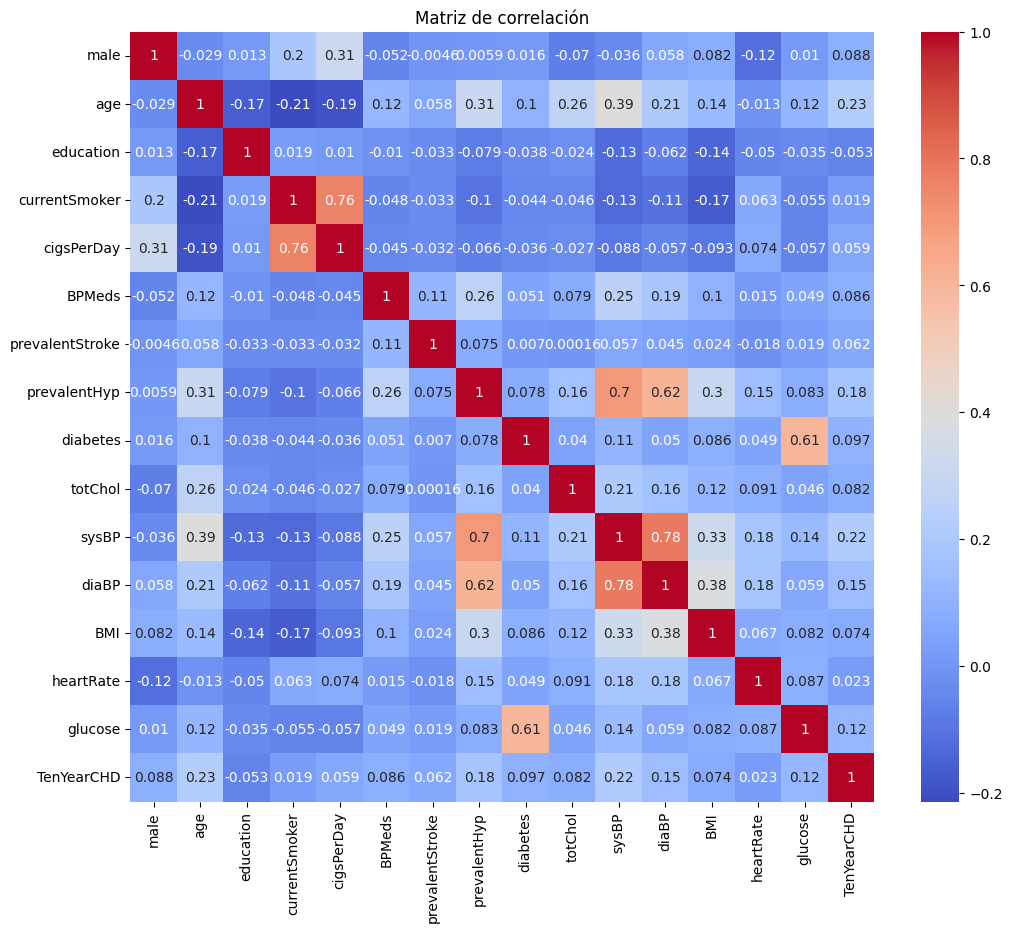

In [76]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

A partir de la matriz de correlación, se identifican varias relaciones relevantes:

- `sysBP` y `diaBP` presentan una correlación alta, lo cual es esperable al tratarse de dos medidas de presión arterial.
- `currentSmoker` y `cigsPerDay` también muestran una correlación alta, ya que el número de cigarrillos depende directamente de si el paciente fuma o no.
- `prevalentHyp` se relaciona con `sysBP` y `diaBP`, coherente con la definición de hipertensión.
- `diabetes` y `glucose` presentan relación, lo cual tiene sentido clínico.

En cuanto a la variable objetivo, las correlaciones individuales no son extremadamente altas. Esto sugiere que el riesgo de enfermedad coronaria no depende de una única variable, sino de la combinación de múltiples factores.

## Análisis bivariado: variables numéricas frente al target

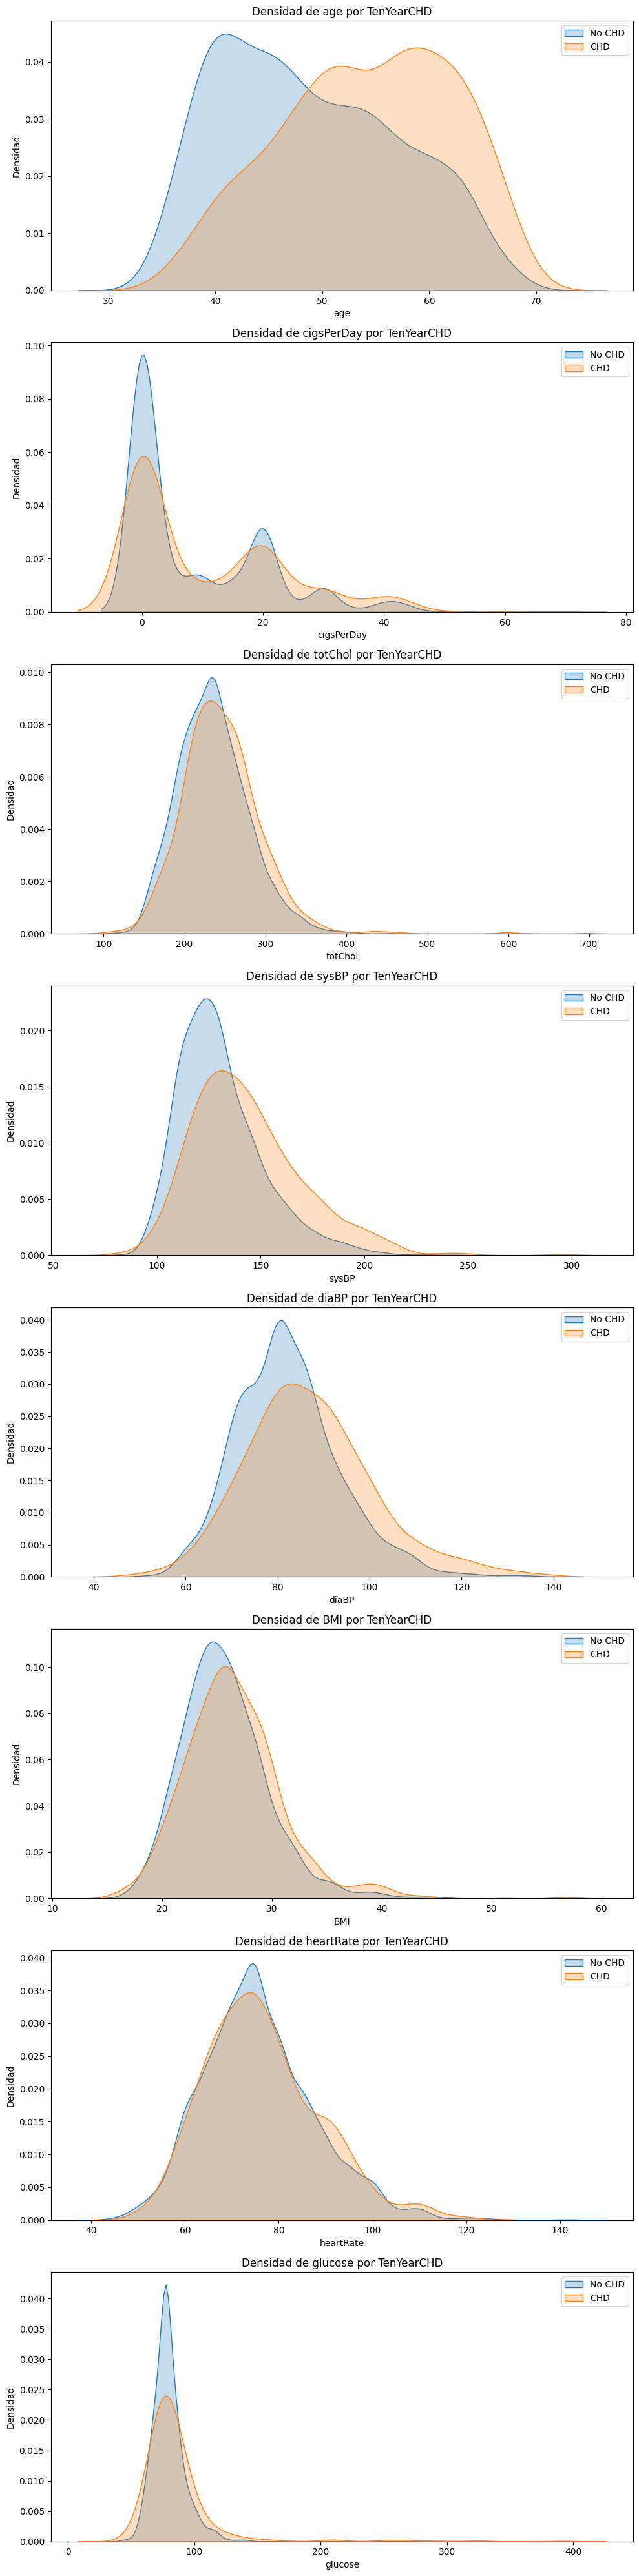

In [77]:
fig, axs = plt.subplots(nrows=len(numeric_cols), ncols=1, figsize=(10, 5 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df_clean[df_clean[target] == 0],
        x=col,
        ax=axs[i],
        label="No CHD",
        fill=True
    )

    sns.kdeplot(
        data=df_clean[df_clean[target] == 1],
        x=col,
        ax=axs[i],
        label="CHD",
        fill=True
    )

    axs[i].set_title(f"Densidad de {col} por {target}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Densidad")
    axs[i].legend()

plt.tight_layout()
plt.show()

En este apartado comparo la distribución de las variables numéricas según la variable objetivo.

Este análisis permite detectar diferencias visuales entre los pacientes que desarrollaron enfermedad coronaria y los que no.

Las variables donde se aprecian diferencias más claras son `age`, `sysBP`, `diaBP` y `glucose`. Otras variables como `BMI`, `totChol` y `cigsPerDay` muestran diferencias más moderadas.

## Boxplots de variables numéricas frente al target

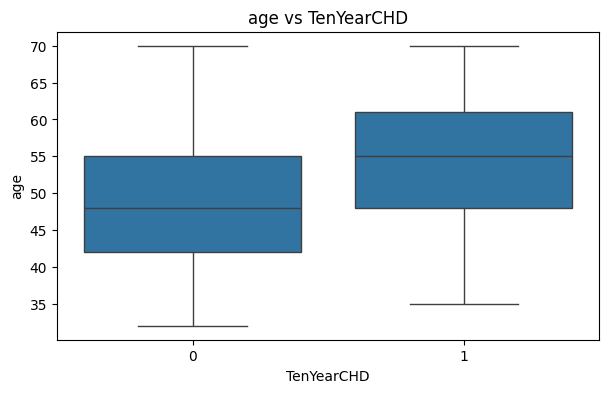

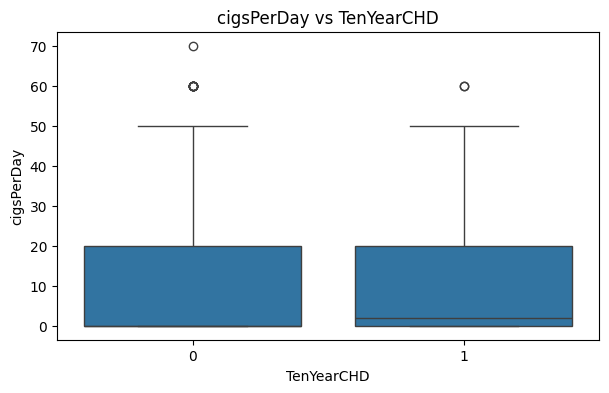

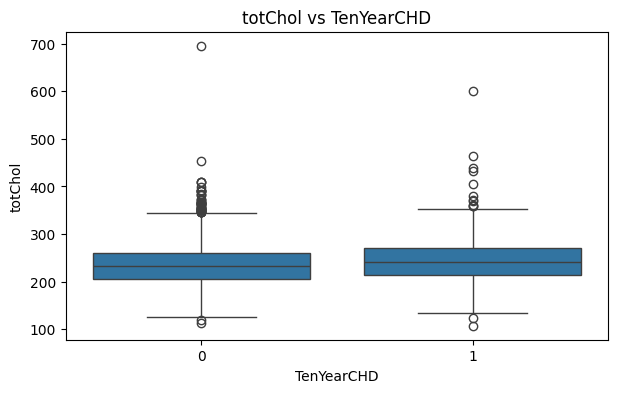

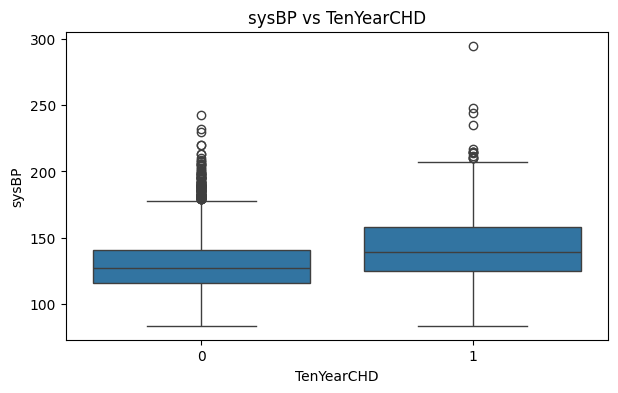

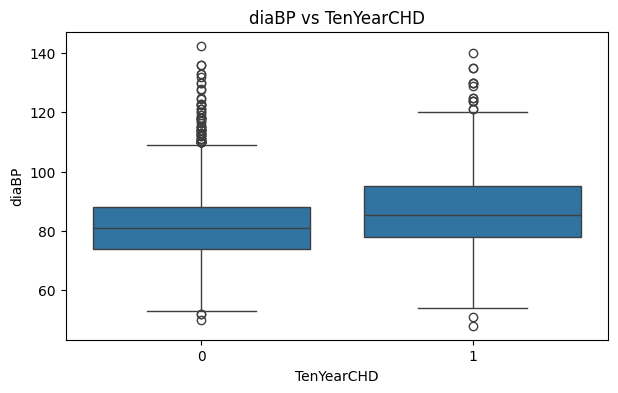

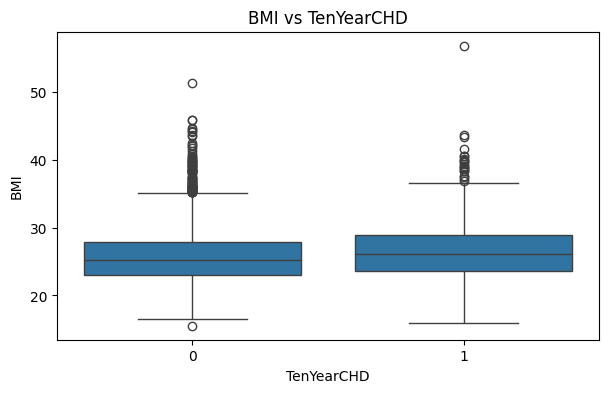

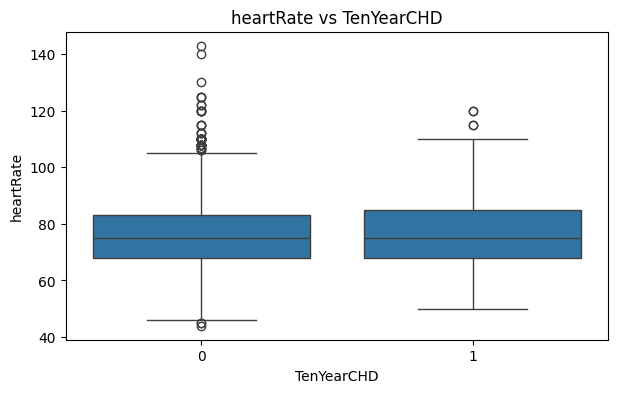

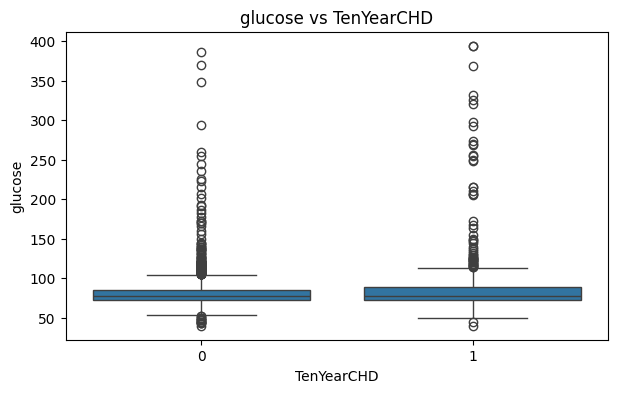

In [78]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=target, y=col, data=df_clean)
    plt.title(f"{col} vs {target}")
    plt.show()

A partir de los boxplots, se observan diferencias claras entre los pacientes que desarrollan enfermedad coronaria y los que no.

- `age`: los pacientes con enfermedad coronaria suelen ser mayores.
- `sysBP` y `diaBP`: los pacientes con enfermedad presentan valores más altos de presión arterial.
- `glucose`, `BMI` y `totChol`: muestran diferencias más moderadas.
- `heartRate`: no muestra una separación clara entre grupos.

Estos resultados permiten empezar a contrastar las hipótesis iniciales.

## Análisis específico del tabaquismo

TenYearCHD,0,1
currentSmoker,,
0,85.501166,14.498834
1,84.105012,15.894988


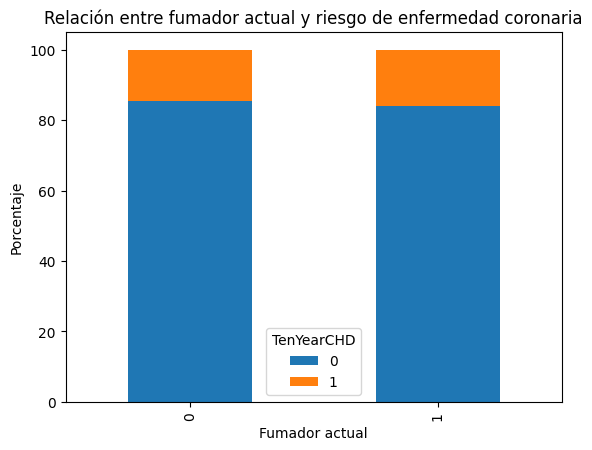

In [79]:
smoker_target = pd.crosstab(
    df_clean["currentSmoker"],
    df_clean[target],
    normalize="index"
) * 100

display(smoker_target)

smoker_target.plot(kind="bar", stacked=True)

plt.title("Relación entre fumador actual y riesgo de enfermedad coronaria")
plt.xlabel("Fumador actual")
plt.ylabel("Porcentaje")
plt.legend(title=target)
plt.show()

En este gráfico se observa la distribución de la variable objetivo en función de si el paciente es fumador o no.

Las proporciones de enfermedad coronaria son similares entre fumadores y no fumadores, aunque existe una ligera mayor incidencia en fumadores.

Sin embargo, la diferencia no es lo suficientemente marcada como para considerar `currentSmoker` como una variable muy discriminante por sí sola.

Es importante destacar que la variable `cigsPerDay` sí muestra diferencias significativas en el análisis estadístico posterior. Esto sugiere que la intensidad del consumo de tabaco puede aportar más información que la variable binaria de fumar o no fumar.

## Test ANOVA

In [80]:
anova_results = []

for col in numeric_cols:
    group0 = df_clean[df_clean[target] == 0][col]
    group1 = df_clean[df_clean[target] == 1][col]
    stat, p = f_oneway(group0, group1)
    anova_results.append([col, stat, p])

anova_df = pd.DataFrame(anova_results, columns=["variable", "F_statistic", "p_value"])
anova_df.sort_values("p_value")

,variable,F_statistic,p_value
0,age,226.853168,5.573313e-50
3,sysBP,208.158627,4.217070e-46
4,diaBP,91.160759,2.170620e-21
7,glucose,63.307530,2.251188e-15
2,totChol,28.512751,9.795875e-08
5,BMI,23.542049,1.266045e-06
1,cigsPerDay,14.668063,1.300534e-04
6,heartRate,2.214058,1.368330e-01


Para complementar el análisis visual, aplico un test ANOVA entre las variables numéricas y la variable objetivo `TenYearCHD`.

Este test permite determinar si existen diferencias estadísticamente significativas entre pacientes con y sin enfermedad coronaria.

Un p-valor inferior a 0.05 indica que existen diferencias significativas entre ambos grupos.

Los resultados muestran que `age`, `sysBP`, `diaBP`, `glucose`, `totChol`, `BMI` y `cigsPerDay` presentan diferencias significativas. Por otro lado, `heartRate` no presenta una relación significativa.

## Test Chi-cuadrado

In [81]:
chi_results = []

for col in cat_cols:
    table = pd.crosstab(df_clean[col], df_clean[target])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append([col, chi2, p])

chi_df = pd.DataFrame(chi_results, columns=["variable", "chi2", "p_value"])
chi_df.sort_values("p_value")

,variable,chi2,p_value
5,prevalentHyp,132.456286,1.188961e-30
6,diabetes,38.482338,5.525144e-10
0,male,32.618335,1.121518e-08
3,BPMeds,30.272895,3.753344e-08
1,education,31.051850,8.289453e-07
4,prevalentStroke,14.033657,1.795676e-04
2,currentSmoker,1.497204,2.211021e-01


Para analizar la relación entre variables categóricas y la variable objetivo, aplico el test Chi-cuadrado.

Este test permite comprobar si existe asociación entre dos variables categóricas.

Las variables que presentan asociación significativa con `TenYearCHD` son `prevalentHyp`, `diabetes`, `male`, `BPMeds`, `education` y `prevalentStroke`.

La variable `currentSmoker` no presenta una relación estadísticamente significativa de forma aislada, lo que refuerza la idea de que el tabaquismo está mejor representado por la intensidad del consumo (`cigsPerDay`) que por la variable binaria.

## Análisis bivariado global frente al target

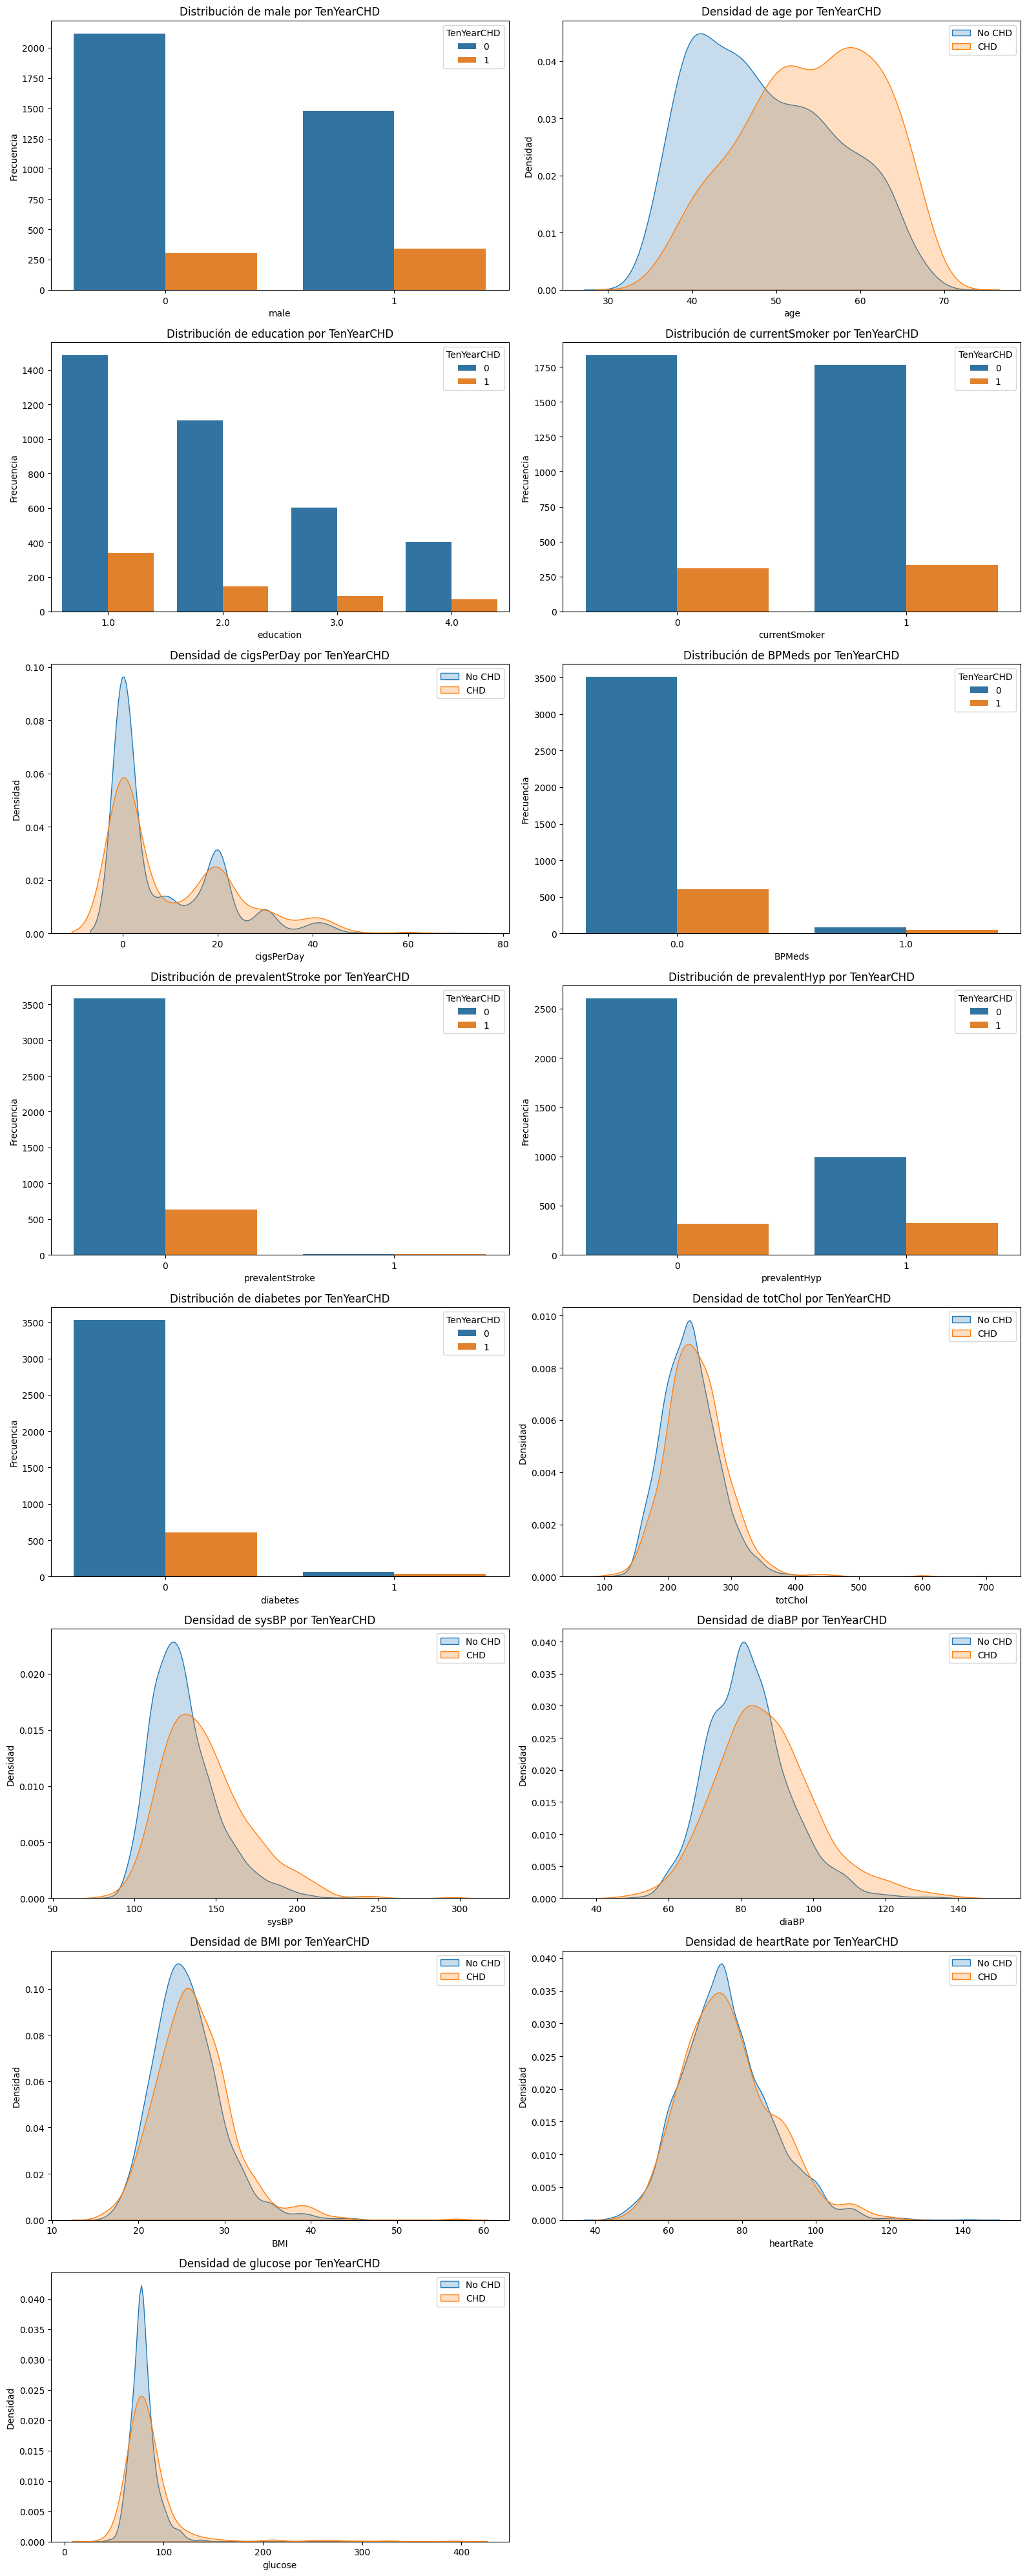

In [82]:
X = df_clean.drop(columns=[target])

fig, axs = plt.subplots(
    nrows=(len(X.columns) + 1) // 2,
    ncols=2,
    figsize=(16, 5 * ((len(X.columns) + 1) // 2))
)

axs = axs.flatten()

for i, column in enumerate(X.columns):
    if column in cat_cols:
        sns.countplot(data=df_clean, x=column, hue=target, ax=axs[i])
        axs[i].set_title(f"Distribución de {column} por {target}")
        axs[i].set_xlabel(column)
        axs[i].set_ylabel("Frecuencia")
        axs[i].legend(title=target)
    else:
        sns.kdeplot(data=df_clean[df_clean[target] == 0], x=column, label="No CHD", fill=True, ax=axs[i])
        sns.kdeplot(data=df_clean[df_clean[target] == 1], x=column, label="CHD", fill=True, ax=axs[i])
        axs[i].set_title(f"Densidad de {column} por {target}")
        axs[i].set_xlabel(column)
        axs[i].set_ylabel("Densidad")
        axs[i].legend()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

Este análisis global permite revisar todas las variables frente al target en una única sección.

Tras revisar las visualizaciones, las variables que mejor diferencian entre pacientes con y sin enfermedad coronaria son `age`, `sysBP`, `diaBP`, `glucose`, `prevalentHyp` y `diabetes`.

También se aprecia que variables como `BMI`, `totChol` y `cigsPerDay` presentan diferencias más moderadas.

En cambio, variables como `heartRate` o `currentSmoker` no muestran una separación clara por sí solas.

## Análisis multivariante

En este apartado resumo las relaciones entre variables analizadas anteriormente.

El análisis multivariante permite observar que el riesgo de enfermedad coronaria no depende de una única variable aislada, sino de la combinación de múltiples factores.

Las variables numéricas muestran relación con el target especialmente en el caso de `age`, `sysBP`, `diaBP`, `glucose`, `totChol`, `BMI` y `cigsPerDay`.

En variables categóricas, el test Chi-cuadrado confirma la relevancia de `prevalentHyp`, `diabetes`, `BPMeds`, `male`, `education` y `prevalentStroke`.

En conjunto, los resultados muestran que los factores clínicos, como presión arterial, glucosa, diabetes e hipertensión, son los más relevantes, aunque también influyen factores de estilo de vida como el consumo de tabaco.

## Contraste de hipótesis iniciales

Al inicio del análisis se planteó que variables como edad, presión arterial, colesterol, glucosa, tabaquismo y variables clínicas podían influir en el riesgo de enfermedad coronaria.

Tras el EDA, puedo concluir que:

- La edad confirma claramente la hipótesis, siendo una de las variables más influyentes.
- La presión arterial (`sysBP` y `diaBP`) también confirma la hipótesis, mostrando diferencias claras entre grupos.
- La glucosa y la diabetes presentan una relación significativa con el riesgo.
- El colesterol (`totChol`) tiene impacto, aunque menor que la edad o la presión arterial.
- El índice de masa corporal (`BMI`) muestra una relación moderada.
- El tabaquismo se confirma parcialmente: `currentSmoker` no es muy fuerte por sí sola, pero `cigsPerDay` sí presenta diferencias significativas.
- Variables como `heartRate` no confirman la hipótesis inicial, ya que no muestran una relación significativa con la variable objetivo.

Por tanto, las hipótesis iniciales se confirman en gran parte, especialmente para las variables clínicas y de presión arterial.

## Conclusiones finales

El objetivo de este EDA era responder a la pregunta de investigación: qué características demográficas, de estilo de vida y clínicas se asocian a un mayor riesgo de desarrollar enfermedad coronaria en los próximos 10 años.

A partir del análisis realizado, las variables más relevantes son:

- Edad (`age`)
- Presión arterial (`sysBP`, `diaBP`)
- Glucosa (`glucose`)
- Hipertensión (`prevalentHyp`)
- Diabetes (`diabetes`)
- Colesterol (`totChol`)
- Índice de masa corporal (`BMI`)
- Consumo de tabaco (`cigsPerDay`)

Los resultados muestran que los factores clínicos tienen un papel especialmente importante. La edad y la presión arterial destacan como los factores más claros, seguidos por glucosa, diabetes, colesterol e índice de masa corporal.

En cuanto a las variables de estilo de vida, el tabaquismo no aparece como una variable fuerte cuando se analiza únicamente como fumador o no fumador, pero sí cobra más importancia al analizar la cantidad de cigarrillos consumidos al día.

También se observa que la variable objetivo está desbalanceada, ya que la mayoría de pacientes no desarrolla enfermedad coronaria. Este punto será importante en fases posteriores si se construyen modelos predictivos.

En conclusión, el riesgo de enfermedad coronaria no depende de una única variable, sino de la combinación de múltiples factores demográficos, clínicos y de estilo de vida.